In [1]:
from pathlib import Path
import torch
import os
import cv2
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
# Setting up paths and environment variables 
data_yaml = '../datasets/warehouse/data.yaml'  # Path to training dataset config
weights_path = 'yolov5s.pt'  # will start with pretrained small model
project_name = 'yolov5_warehouse'
img_size = 640
batch_size = 16
epochs = 50

# Launching YOLOv5 training
import sys  
sys.path.append('../yolov5')
from train import run

run(imgsz=img_size,
    batch=batch_size,
    epochs=epochs,
    data=data_yaml,
    weights=weights_path,
    name=project_name)

/Users/mohamedelsawy/PycharmProjects/supply-chain-object-tracking/notebooks/../yolov5/utils/general.py:32: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
train: weights=yolov5s.pt, cfg=, data=../datasets/warehouse/data.yaml, hyp=../yolov5/data/hyps/hyp.scratch-low.yaml, epochs=50, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=../yolov5/data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=../yolov5/runs/train, name=yolov5_warehouse, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-

Namespace(weights='yolov5s.pt', cfg='', data='../datasets/warehouse/data.yaml', hyp={'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'warmup_bias_lr': 0.1, 'box': 0.05, 'cls': 0.5, 'cls_pw': 1.0, 'obj': 1.0, 'obj_pw': 1.0, 'iou_t': 0.2, 'anchor_t': 4.0, 'fl_gamma': 0.0, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'mosaic': 1.0, 'mixup': 0.0, 'copy_paste': 0.0}, epochs=50, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=PosixPath('../yolov5/data/hyps'), resume_evolve=None, bucket='', cache=None, image_weights=False, device='', multi_scale=False, single_cls=False, optimizer='SGD', sync_bn=False, workers=8, project='../yolov5/runs/train', name='yolov5_warehouse', exist_ok=False, quad=False, cos_lr=False, label_smoothi

In [7]:
# Load your fine-tuned model from local YOLOv5 repo

model = torch.hub.load(
    '../yolov5',
    'custom',
    path='../yolov5/runs/train/yolov5_warehouse2/weights/best.pt',  # fine-tuned model weights
    source='local',
    force_reload=True
)

model.conf = 0.6

YOLOv5 🚀 v7.0-422-g2540fd4c Python-3.11.7 torch-2.7.1 CPU

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


In [8]:
test_images_dir = Path('../datasets/warehouse/test/images')
output_dir = Path('../outputs/test_predictions')
output_dir.mkdir(parents=True, exist_ok=True)

results_list = []

# Loop through all test images
for img_path in tqdm(sorted(test_images_dir.glob('*.jpg'))):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Inference
    results = model(img_rgb)
    boxes = results.xyxy[0]

    # Save annotated image
    annotated = results.render()[0]
    out_path = output_dir / img_path.name
    cv2.imwrite(str(out_path), cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))

    # Collect results
    for *xyxy, conf, cls in boxes:
        x1, y1, x2, y2 = map(int, xyxy)
        results_list.append({
            "filename": img_path.name,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "confidence": float(conf),
            "class_id": int(cls),
            "class_name": model.names[int(cls)]
        })

# Save results as CSV
df = pd.DataFrame(results_list)
csv_path = output_dir / "test_detections.csv"
df.to_csv(csv_path, index=False)

print(f"✅ Evaluation complete. Results saved to: {csv_path}")

  0%|                                                    | 0/23 [00:00<?, ?it/s]/Users/mohamedelsawy/PycharmProjects/supply-chain-object-tracking/notebooks/../yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
  4%|█▉                                          | 1/23 [00:00<00:03,  6.06it/s]/Users/mohamedelsawy/PycharmProjects/supply-chain-object-tracking/notebooks/../yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
  9%|███▊                                        | 2/23 [00:00<00:02,  7.43it/s]/Users/mohamedelsawy/PycharmProjects/supply-chain-object-tracking/notebooks/../yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  wit

✅ Evaluation complete. Results saved to: ../outputs/test_predictions/test_detections.csv


In [9]:
df = pd.read_csv('../outputs/test_predictions/test_detections.csv')
df.head()

,filename,x1,y1,x2,y2,confidence,class_id,class_name
0,DJI_0257_JPG.rf.a4ff0c0021b7a78eae392cc92adcd9...,342,323,398,358,0.920733,0,0
1,DJI_0257_JPG.rf.a4ff0c0021b7a78eae392cc92adcd9...,344,425,400,462,0.919414,0,0
2,DJI_0257_JPG.rf.a4ff0c0021b7a78eae392cc92adcd9...,241,326,297,364,0.913789,0,0
3,DJI_0257_JPG.rf.a4ff0c0021b7a78eae392cc92adcd9...,341,355,397,392,0.911485,0,0
4,DJI_0257_JPG.rf.a4ff0c0021b7a78eae392cc92adcd9...,514,425,565,461,0.911141,0,0


In [11]:
%matplotlib inline

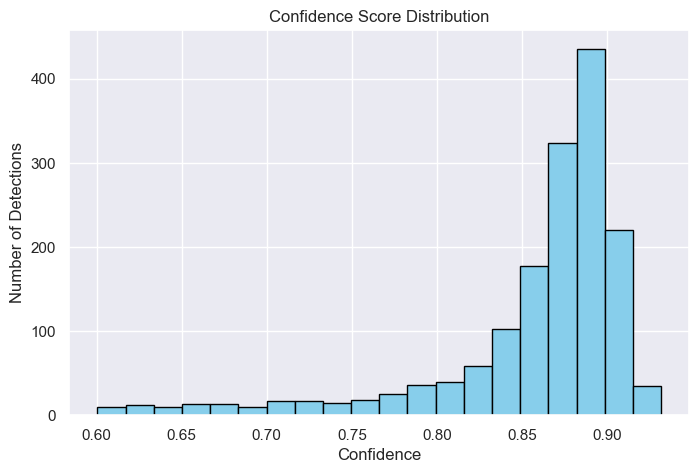

In [13]:
plt.figure(figsize=(8, 5))
df['confidence'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Confidence Score Distribution')
plt.xlabel('Confidence')
plt.ylabel('Number of Detections')
plt.grid(True)
plt.show()

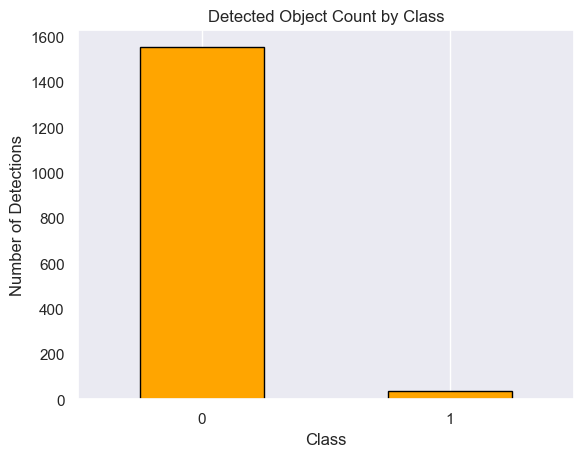

In [14]:
df['class_name'].value_counts().plot(kind='bar', color='orange', edgecolor='black')
plt.title('Detected Object Count by Class')
plt.xlabel('Class')
plt.ylabel('Number of Detections')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

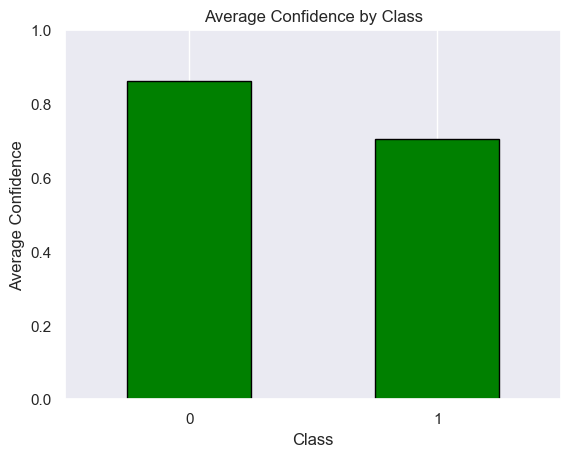

In [15]:
df.groupby('class_name')['confidence'].mean().sort_values(ascending=False).plot(
    kind='bar', color='green', edgecolor='black'
)
plt.title('Average Confidence by Class')
plt.ylabel('Average Confidence')
plt.xlabel('Class')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

Processing: test_image.jpeg


/Users/mohamedelsawy/PycharmProjects/supply-chain-object-tracking/notebooks/../yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


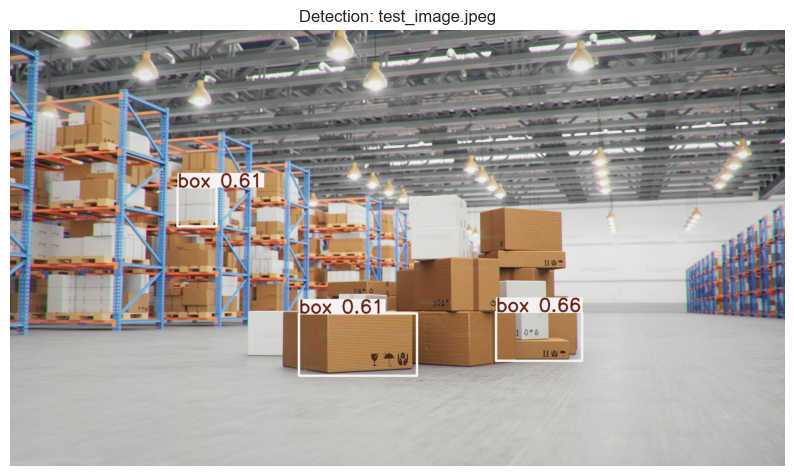

Processing: test_image_2.jpg


/Users/mohamedelsawy/PycharmProjects/supply-chain-object-tracking/notebooks/../yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


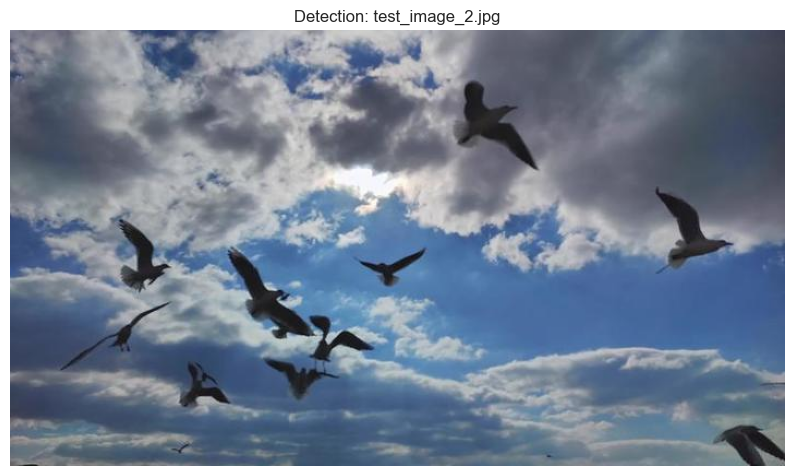

Processing: test_image_3.jpg


/Users/mohamedelsawy/PycharmProjects/supply-chain-object-tracking/notebooks/../yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


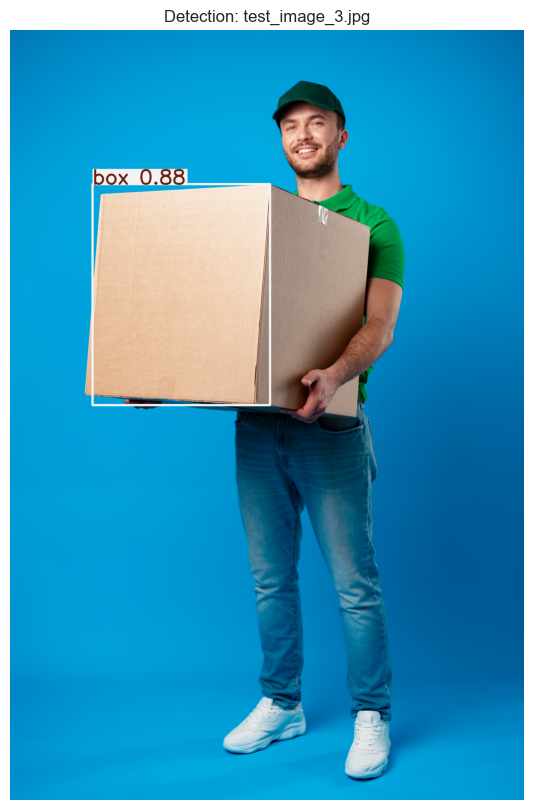

In [24]:
image_dir = Path('../data')
image_paths = sorted(list(image_dir.glob('*.jpg')) + list(image_dir.glob('*.jpeg')))

if not image_paths:
    print("❌ No .jpg images found in ../data")
else:
    for img_path in image_paths:
        print(f"Processing: {img_path.name}")
        
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            print(f"⚠️ Skipping unreadable: {img_path}")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        results = model(img_rgb)

        annotated = results.render()[0]
        plt.figure(figsize=(10, 10))
        plt.imshow(annotated)
        plt.axis('off')
        plt.title(f"Detection: {img_path.name}")
        plt.show()

In [26]:
# --- Paths ---
input_video_path = '../data/test_video2.mp4'
output_video_path = '../outputs/wh_annotated_video.mp4'
output_csv_path = '../outputs/wh_video_detections.csv'
weights_path = '../yolov5/runs/train/yolov5_warehouse/weights/best.pt'

# # --- Load model ---
# model = torch.hub.load('../yolov5', 'custom', path=weights_path, source='local')
# model.conf = 0.4 

# --- Setup video I/O ---
cap = cv2.VideoCapture(input_video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# --- Inference loop ---
detections = []
frame_index = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Run detection
    results = model(frame)
    boxes = results.xyxy[0]  # x1, y1, x2, y2, conf, class

    # Draw boxes
    annotated = results.render()[0]
    out.write(annotated)

    # Save detection details
    for *xyxy, conf, cls in boxes:
        x1, y1, x2, y2 = map(int, xyxy)
        detections.append({
            "frame": frame_index,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "confidence": float(conf),
            "class_id": int(cls),
            "class_name": model.names[int(cls)]
        })

    frame_index += 1

# --- Save results ---
cap.release()
out.release()
pd.DataFrame(detections).to_csv(output_csv_path, index=False)

print(f"✅ Finished processing {frame_index} frames")
print(f"📹 Output video saved to: {output_video_path}")
print(f"📄 CSV detections saved to: {output_csv_path}")

/Users/mohamedelsawy/PycharmProjects/supply-chain-object-tracking/notebooks/../yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/Users/mohamedelsawy/PycharmProjects/supply-chain-object-tracking/notebooks/../yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/Users/mohamedelsawy/PycharmProjects/supply-chain-object-tracking/notebooks/../yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/Users/mohamedelsawy/PycharmProjects/supply-chain-object-tracking/notebooks/../yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', ar

✅ Finished processing 284 frames
📹 Output video saved to: ../outputs/wh_annotated_video.mp4
📄 CSV detections saved to: ../outputs/wh_video_detections.csv


In [28]:
video_detections = pd.read_csv('../outputs/wh_video_detections.csv')
video_detections.head()

,frame,x1,y1,x2,y2,confidence,class_id,class_name
0,0,1387,564,1784,946,0.694048,2,box
1,1,1382,589,1786,957,0.691396,2,box
2,1,3560,938,3836,1363,0.613330,2,box
3,2,1393,607,1791,967,0.683351,2,box
4,2,956,635,1276,846,0.637906,2,box


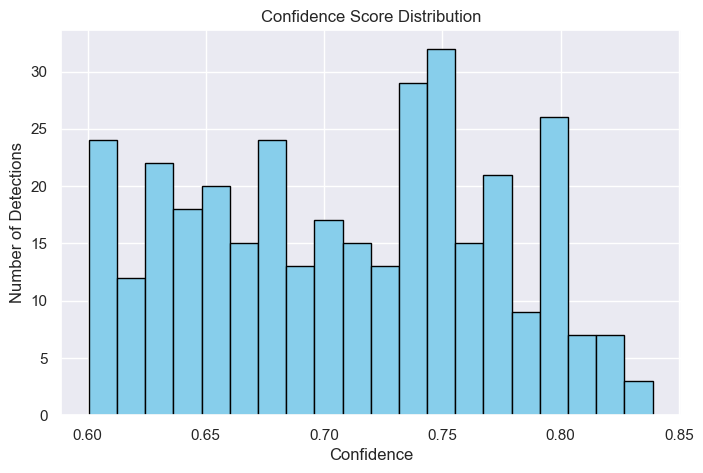

In [31]:
# import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
video_detections['confidence'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Confidence Score Distribution')
plt.xlabel('Confidence')
plt.ylabel('Number of Detections')
plt.grid(True)
plt.show()

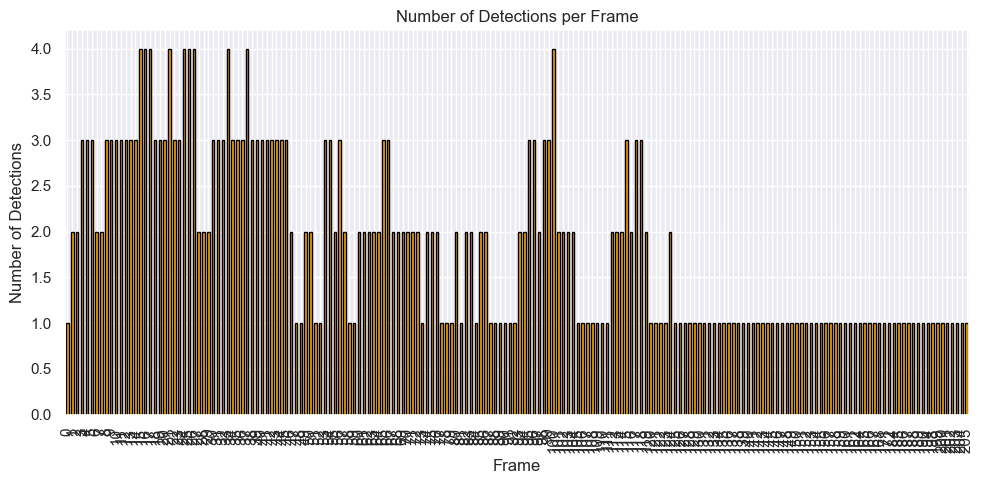

In [32]:
plt.figure(figsize=(10, 5))
video_detections['frame'].value_counts().sort_index().plot(kind='bar', color='orange', edgecolor='black')
plt.title('Number of Detections per Frame')
plt.xlabel('Frame')
plt.ylabel('Number of Detections')
plt.tight_layout()
plt.show()